In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import os

In [6]:
df = gpd.read_file('data/arctic_communities.geojson')

In [9]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   admin          15 non-null     object  
 1   country        15 non-null     object  
 2   n_communities  15 non-null     int64   
 3   geometry       15 non-null     geometry
dtypes: geometry(1), int64(1), object(2)
memory usage: 612.0+ bytes


In [12]:
df.describe

<bound method NDFrame.describe of                        admin country  n_communities  \
0   United States of America      US            115   
1             United Kingdom      GB             96   
2                     Sweden      SE            133   
3                     Russia      RU            774   
4                     Norway      NO             48   
5                  Lithuania      LT             26   
6                     Latvia      LV             25   
7                    Iceland      IS              5   
8                    Finland      FI             99   
9                    Estonia      EE             14   
10                 Greenland      GL              1   
11             Faroe Islands      FO              1   
12                   Denmark      DK             72   
13                    Canada      CA              7   
14                   Belarus      BY              8   

                                             geometry  
0   MULTIPOLYGON (((-132.7468

Brain storming

## 2. Check geometry types
Run df.geom_type. Write a brief explanation about the output in a markdown cell.

Create an if-else statement that:

prints “Multiple feature types:” followed by the unique geometry types (no repetition) in the geodataframe if not all the features are polygons, and

prints “All features are:” followed by the unique geometry type if all the features in the geodataframe have the same geometry type.

Wrap up your code into a function named check_polygons that receives a single geodataframe as its parameter and prints out a message about the geometry types in the geodataframe.

In [52]:
# Create a function name check_polygons that receives a single geodataframe as its paramter and prints out a message stating whether all the geometry types are polygons
df.geom_type

0     MultiPolygon
1     MultiPolygon
2     MultiPolygon
3     MultiPolygon
4     MultiPolygon
5     MultiPolygon
6          Polygon
7          Polygon
8     MultiPolygon
9     MultiPolygon
10    MultiPolygon
11    MultiPolygon
12    MultiPolygon
13    MultiPolygon
14         Polygon
dtype: object

In [53]:
# if the number of geom in that list is > then 1 we will like to print multi fea.. 
if  len(df.geom_type.unique()) > 1:
    print("Multiple Feature types")
else: 
    print("All features are")
# or
# if df.geom_type.unique().size > 1:
#     print(f"Multiple feature tpes {df.geom_type.uniwue()}")
# else:
#     print(f"All feature are: {df.geom_type.uniwue()}")

Multiple Feature types


In [15]:
def polyons (df):
    if  len(df.geom_type.unique()) > 1:
        print("Multiple Feature types")
    else: 
        print("All features are")
polyons(df)

# or
# def check_polygons(df):
# if df.geom_type.unique().size > 1:
#     print(f"Multiple feature tpes {df.geom_type.uniwue()}")
# else:
#     print(f"All feature are: {df.geom_type.uniwue()}")

Multiple Feature types


## 3. Explode polygons
Overwrite the df geodataframe with the output from the explode method with the index_parts parameter set to False. Read the documentation for the method and use a markdown cell to write a brief explanation of what is being done.

Reset the index of df.

Use your check_polygons function to verify that df only has features of type polygon.

In [54]:
exploded = df.explode(index_parts = False).reset_index()
exploded

#or
#df = df.explode(column ='geometry', index_parts = False).rest_index() = False keeps the multi level index

,index,admin,country,n_communities,geometry
0,0,United States of America,US,115,"POLYGON ((-132.74687 56.52568, -132.75762 56.5..."
1,0,United States of America,US,115,"POLYGON ((-132.77988 56.24727, -132.83096 56.2..."
2,0,United States of America,US,115,"POLYGON ((-134.31274 58.22891, -134.31987 58.2..."
3,0,United States of America,US,115,"POLYGON ((-145.11851 60.33711, -145.15049 60.3..."
4,0,United States of America,US,115,"POLYGON ((-144.56563 59.81841, -144.61357 59.8..."
...,...,...,...,...,...
476,13,Canada,CA,7,"POLYGON ((-109.16641 67.98237, -109.05391 67.9..."
477,13,Canada,CA,7,"POLYGON ((-108.09272 67.00518, -107.96646 66.9..."
478,13,Canada,CA,7,"POLYGON ((-109.32314 67.99087, -109.36084 67.9..."
479,13,Canada,CA,7,"POLYGON ((-139.04312 69.57690, -139.12573 69.5..."


In [55]:
# check 
polyons(exploded)
#check_polygond(df)

All features are


## 4. Compute minimum y-coordinate for polygons
At this point, every row in your df should be a single polygon.

Select the first row of df using iloc. What kind of Python object is this?

Select the geometry of the first row of df. What kind of Python object is this?

Use the bounds attribute for shapely Polygons to select the southern-most bound of the first polygon in df.

Create a function min_y that receives a single row of a geodataframe as its parameter and returns the minimum y-coordinate of its bounding box.

Use the min_y function and the apply method for data frames to create a new column miny in df which has the minimum y coordinate.

In [27]:
type(df.iloc[0])

pandas.core.series.Series

In [29]:
type(df.geom_type[0])

str

In [37]:
type(exploded.iloc[0].geometry)

shapely.geometry.polygon.Polygon

In [39]:
df.iloc[0].geometry.bounds[1]
# or
#df.loc[0, "geometry"].bounds[1}]

18.963916015625003

In [58]:
# def func(nrow):
#    return(df.iloc[nrow].geometry.bounds[1])
# or
def min_y(i):
    y = i.geometry.bounds[1]
    return(y)
min_y(df.iloc[0])

18.963916015625003

In [49]:
#func(1)

50.021386718749994

In [59]:
#df.apply(func, axis = 1)
df['min_y'] = df.apply(func = min_y, axis = 1)
df.head()

,admin,country,n_communities,geometry,min_y
0,United States of America,US,115,"MULTIPOLYGON (((-132.74687 56.52568, -132.7576...",18.963916
1,United Kingdom,GB,96,"MULTIPOLYGON (((-2.66768 51.62300, -2.74214 51...",50.021387
2,Sweden,SE,133,"MULTIPOLYGON (((19.07646 57.83594, 18.99375 57...",55.346387
3,Russia,RU,774,"MULTIPOLYGON (((145.88154 43.45952, 145.89561 ...",41.199268
4,Norway,NO,48,"MULTIPOLYGON (((20.62217 69.03687, 20.49199 69...",58.020947


In [60]:
artic_countries = df[df['min_y'] >= 40]

In [62]:
artic_countries = artic_countries.to_crs('epsg:3413')

<Axes: >

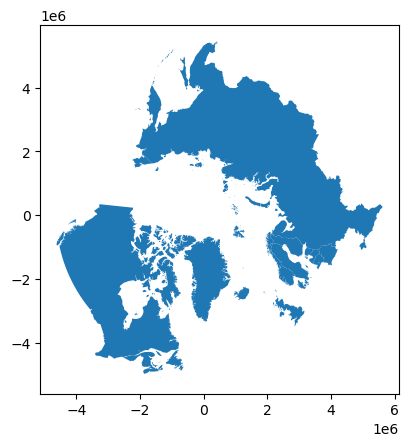

In [63]:
artic_countries.plot()